In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


df = pd.read_csv(r"C:\Users\arnau\Documents\Kaggle_House_Price\Kaggle_House_Price_DATA\train.csv")

#Na ne correspond pas à l'absence de donnée mais au fait que la maison ne possède pas de piscine
df['PoolQC'] = df['PoolQC'].fillna('No')

In [125]:
#idem pour MiscFeature, Alley, Fence, FireplaceQu, GarageFinish, GarageQual, GarageType, GarageYrBlt, GarageCond, BsmtFinType2, BsmtExposure, BsmtCond, BsmtQual, BsmtFinType1, MasVnrType
No_col = ['MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageType', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType1', 'MasVnrType']

for var in No_col :
    df[var] = df[var].fillna('No')

df.isnull().sum().sort_values(ascending=False)

LotFrontage      259
MasVnrArea         8
Electrical         1
Id                 0
MSSubClass         0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [126]:
#On cherche maintenant à s'occuper des valeurs réellement manquantes c'est-à-dire LotFrontage, MasVnrArea et Electrical
#LotFrontage, MasVnrArea -> numérique

var_numerique = ['LotFrontage','MasVnrArea']
for var in var_numerique :
    med = df[var].median()
    df[var] = df[var].fillna(med)

#Electrique -> catégorielle
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [127]:
#On a reperer deux points semblant peu cohérent avec des prices inférieur à 200 000 et la superficie supérieur à 4500, pour ne pas que cela biaise notre classification. On supprimer également la valeur extreme qui de TotalBsmtSF qui vaut 6000.

df = df.drop(df[(df['SalePrice'] < 200000) & (df['GrLivArea'] > 4000)].index)
df = df.drop(df[df['TotalBsmtSF'] > 5000].index)

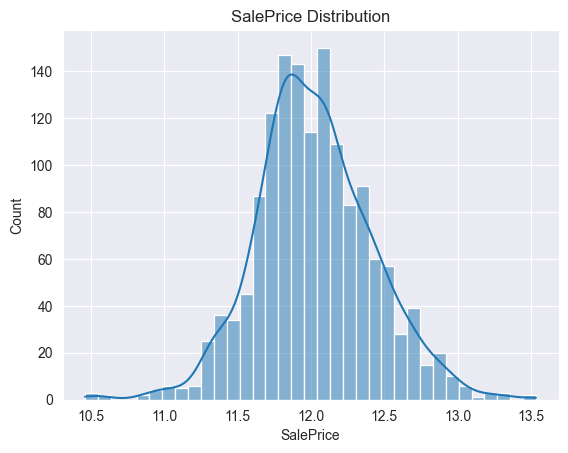

In [128]:
#On souhaite maintenant normaliser la variable SalePrice car la skewness est de 1.882
df['SalePrice'] = np.log1p(df['SalePrice'])
sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

In [129]:
#Ordinal Encoder
quality_map = {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    df[col] = df[col].map(quality_map)

In [130]:
df['BsmtExposure'] = df['BsmtExposure'].map({'No': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})

In [131]:
bsmt_fin_map = {'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin_map)

In [132]:
df['GarageFinish'] = df['GarageFinish'].map({'No': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})

In [133]:
df['LandSlope'] = df['LandSlope'].map({'Gtl': 1, 'Mod': 2, 'Sev': 3})

In [134]:
df['Alley'] = df['Alley'].map({'No': 0, 'Grvl': 1, 'Pave': 2})

In [135]:
df['Fence'] = df['Fence'].map({'No': 0, 'MnWw': 1, 'MnPrv': 2, 'GdWo': 3, 'GdPrv': 4})

In [136]:
df['Functional'] = df['Functional'].map({'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8})

In [137]:
df['PavedDrive'] = df['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})

In [138]:
#One Hot Encoder
onehot_cols = [
    'MSZoning',
    'Street',
    'LotShape',
    'LandContour',
    'LotConfig',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'GarageType',
    'SaleType',
    'SaleCondition',
    'MSSubClass'
]

df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

In [139]:
print(df[cols_a_stand].dtypes)

LotFrontage      float64
LotArea            int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
GrLivArea          int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
PoolArea           int64
MiscVal            int64
YearBuilt          int64
YearRemodAdd       int64
GarageYrBlt       object
dtype: object


In [140]:
df['GarageYrBlt'] = pd.to_numeric(df['GarageYrBlt'], errors='coerce')

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())

# Vérifier
print(df['GarageYrBlt'].dtype)
print(df['GarageYrBlt'].isnull().sum())

float64
0


In [141]:
#Standardisation des variables numériques
cols_a_stand = [
    'LotFrontage', 'LotArea', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', '2ndFlrSF', 'GrLivArea',
    'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
    'EnclosedPorch', 'PoolArea', 'MiscVal',
    'YearBuilt', 'YearRemodAdd', 'GarageYrBlt'
]

scaler = StandardScaler()
df[cols_a_stand] = scaler.fit_transform(df[cols_a_stand])

In [142]:
df.head(10)

,Id,LotFrontage,LotArea,Alley,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190
0,1,-0.221328,-0.203934,0,AllPub,1,7,5,1.052959,0.880362,...,True,False,False,False,False,False,False,False,False,False
1,2,0.491760,-0.087252,0,AllPub,1,6,8,0.158428,-0.428115,...,False,False,False,False,False,False,False,False,False,False
2,3,-0.078710,0.080162,0,AllPub,1,7,5,0.986698,0.831900,...,True,False,False,False,False,False,False,False,False,False
3,4,-0.459024,-0.092325,0,AllPub,1,7,5,-1.862551,-0.718888,...,False,True,False,False,False,False,False,False,False,False
4,5,0.681917,0.385566,0,AllPub,1,8,5,0.953567,0.734975,...,True,False,False,False,False,False,False,False,False,False
5,6,0.729456,0.370853,0,AllPub,1,5,5,0.721651,0.492665,...,False,False,False,False,False,False,False,False,False,False
6,7,0.254064,-0.038144,0,AllPub,1,8,5,1.086090,0.977286,...,False,False,False,False,False,False,False,False,False,False
7,8,-0.031171,-0.007908,0,AllPub,1,7,6,0.059036,-0.573501,...,True,False,False,False,False,False,False,False,False,False
8,9,-0.886877,-0.440343,0,AllPub,1,7,5,-1.332458,-1.688130,...,False,False,False,False,False,False,False,False,False,False
9,10,-0.934416,-0.308441,0,AllPub,1,5,6,-1.067412,-1.688130,...,False,False,False,False,False,False,False,False,False,True


In [144]:
df.to_pickle('df_preprocessed.pkl')
print(f"NaN restants : {df.isnull().sum().sum()}")

NaN restants : 0
